In [1]:
import tensorflow as tf 
from tensorflow import keras 
import tensorflow_addons as tfa
import tensorflow_hub as hub 
from sklearn.metrics import mean_absolute_error 
import numpy as np 
import datetime
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Activation, Dense, Flatten, Conv2D, MaxPooling2D, AveragePooling2D, BatchNormalization, PReLU
import os
import warnings

# Ignore irrelevant warning messages for cleaner output
warnings.filterwarnings('ignore')

c:\Users\ALFIAN\anaconda3\envs\env_insightface\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\ALFIAN\anaconda3\envs\env_insightface\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.11.0 and strictly below 2.14.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.15.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do no

In [2]:
train_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//train_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

valid_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//val_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds, valid_ds

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 10, 112, 112, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 10, 112, 112, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>)

Load Arcface


In [3]:
from models import create_arcface_model

# Load dengan weights (default)
arcface_112 = create_arcface_model(load_weights=True)
arcface_112.trainable = False

arcface_112.summary()



✓ Successfully loaded weights from C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//arcface_weights.h5
Model: "ArcFace"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 112, 112, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 114, 114, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         1728      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)  

✓ Successfully loaded weights from C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//arcface_weights.h5


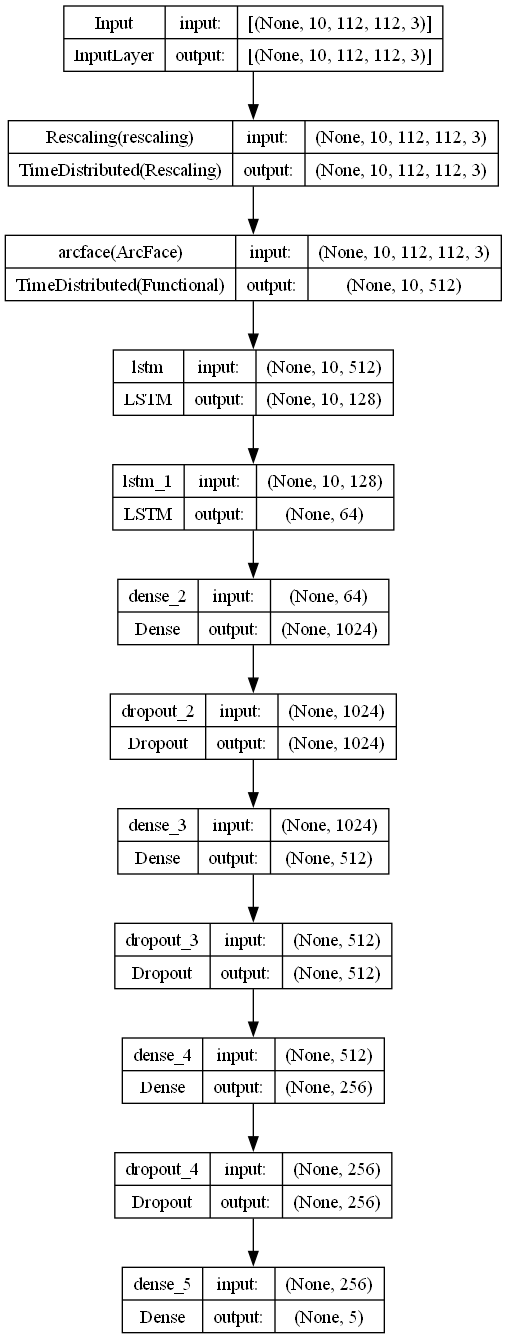

In [4]:
from tensorflow import keras
from models import create_arcface_model
from tensorflow.keras import regularizers

# Load ArcFace model
arcface112 = create_arcface_model()
arcface112.trainable = False

# Build model dengan TimeDistributed untuk sequence input
inputs = keras.layers.Input(shape=(10, 112, 112, 3), name='Input')

# Preprocessing
x = keras.layers.TimeDistributed(keras.layers.Rescaling(scale=1./255.0), name='Rescaling')(inputs)

# ArcFace feature extractor (tetap dibekukan)
x = keras.layers.TimeDistributed(arcface112, name='arcface')(x)

# LSTM layers
x = keras.layers.LSTM(units=128, return_sequences=True)(x)
x = keras.layers.LSTM(units=64)(x)

# Dense + Dropout + Regularization
x = keras.layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.3)(x)

x = keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.3)(x)

x = keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = keras.layers.Dropout(0.5)(x)

# Output
x = keras.layers.Dense(5, activation='sigmoid')(x)

# Build model
model = keras.models.Model(inputs=inputs, outputs=x)

# INI YANG MEMUNCULKAN GAMBAR!
keras.utils.plot_model(model, show_shapes=True)


In [5]:
t = datetime.datetime.now().strftime("%m%d_%H%M%S")

# optimizer = keras.optimizers.Adam(learning_rate=0.001)
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
# optimizer = tfa.optimizers.RectifiedAdam(learning_rate=0.0001)
# optimizer = keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)


early_stopping = keras.callbacks.EarlyStopping(patience=10, verbose=1)
check_point    = keras.callbacks.ModelCheckpoint(filepath='./weights/faces/'+str(t)+'/face.t5',
                            monitor='val_mae',
                            mode='min',
                            save_best_only=True,
                            save_weights_only=True,
                            verbose=1)

model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])

In [6]:
history = model.fit(train_ds, validation_data=valid_ds, batch_size=8, epochs=100, callbacks=[early_stopping, check_point])

Epoch 1/100


8/8 [==============================] - ETA: 0s - loss: 11.6383 - mae: 0.4977
Epoch 1: val_mae improved from inf to 0.49278, saving model to ./weights/faces/1111_221541\face.t5
8/8 [==============================] - 28s 3s/step - loss: 11.6383 - mae: 0.4977 - val_loss: 11.5426 - val_mae: 0.4928
Epoch 2/100
8/8 [==============================] - ETA: 0s - loss: 11.4327 - mae: 0.4871
Epoch 2: val_mae improved from 0.49278 to 0.47821, saving model to ./weights/faces/1111_221541\face.t5
8/8 [==============================] - 21s 3s/step - loss: 11.4327 - mae: 0.4871 - val_loss: 11.2682 - val_mae: 0.4782
Epoch 3/100
8/8 [==============================] - ETA: 0s - loss: 11.1207 - mae: 0.4702
Epoch 3: val_mae improved from 0.47821 to 0.45938, saving model to ./weights/faces/1111_221541\face.t5
8/8 [==============================] - 21s 3s/step - loss: 11.1207 - mae: 0.4702 - val_loss: 10.9404 - val_mae: 0.4594
Epoch 4/100
8/8 [==============================] - ETA: 0s - loss: 10

### Load weights

In [7]:
model.load_weights('./weights/faces/1111_221541/face.t5')

## Evaluation

### Training data

In [8]:
train_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//train_ds') 
loss, mae = model.evaluate(train_ds)
(1-mae)*100

8/8 [==============================] - 15s 2s/step - loss: 0.4619 - mae: 0.0494


95.06335370242596

In [9]:
y_true = np.concatenate([y for x,y in train_ds])
y_pred = model.predict(train_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

8/8 [==============================] - 18s 2s/step


(array([94.94952 , 95.11987 , 94.95099 , 95.229164, 95.06721 ],
       dtype=float32),
 95.0633529573679)

### Validation data

In [10]:
valid_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//val_ds') 
loss, mae = model.evaluate(valid_ds)
(1-mae)*100

3/3 [==============================] - 5s 2s/step - loss: 0.4619 - mae: 0.0494


95.06319276988506

In [11]:
y_true = np.concatenate([y for x,y in valid_ds])
y_pred = model.predict(valid_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 5s 2s/step


(array([94.94934 , 95.119774, 94.95085 , 95.22896 , 95.06704 ],
       dtype=float32),
 95.06319276988506)

### Test data

In [12]:
test_ds = tf.data.Dataset.load('C://Users//ALFIAN//TA_CODING//ZIP_FILE//arcface_oceanmodel//ocean-project-deepface//data//videoface_100//test_ds')
loss, mae = model.evaluate(test_ds)
(1-mae)*100

3/3 [==============================] - 5s 2s/step - loss: 0.4619 - mae: 0.0494


95.06281837821007

In [13]:
y_true = np.concatenate([y for x,y in test_ds])
y_pred = model.predict(test_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 5s 2s/step


(array([94.94894 , 95.11944 , 94.950386, 95.22865 , 95.06668 ],
       dtype=float32),
 95.06281837821007)

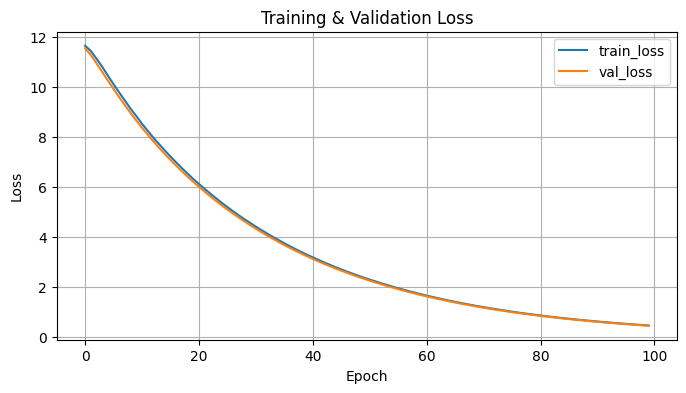

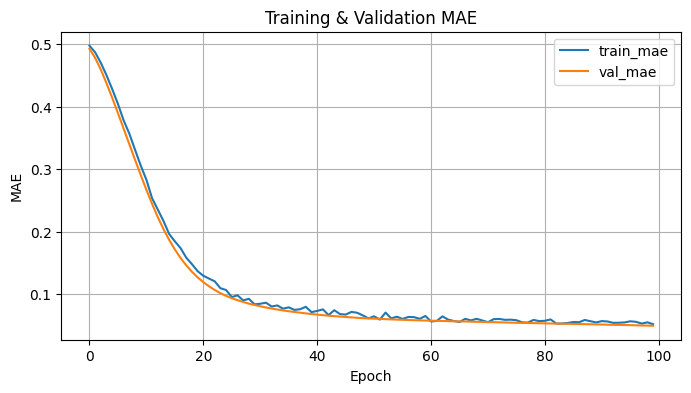

In [14]:
import matplotlib.pyplot as plt

# 1) Plot Loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'],    label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2) Plot MAE (atau metric lain yang kamu pakai)
plt.figure(figsize=(8,4))
plt.plot(history.history['mae'],     label='train_mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.title('Training & Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()